# 02 — Сравнение и визуализация результатов моделей

Этот ноутбук объединяет результаты **всех обученных моделей** на общей тестовой
выборке (5 236 отзывов) и не обучает новых моделей:

- **MLP, CNN, BiLSTM, CNN+BiLSTM** — нейросетевые модели с нуля
  (прогон `01_deep_learning_models.ipynb`);
- **PhoBERT (frozen) + MLP** — замороженный трансформер + классификационная голова
  (прогон `03_phobert_feature_extraction.ipynb`).

Все модели использовали **одинаковый пайплайн предобработки** (`src/preprocessing.py`)
и **одинаковое разбиение** train/test (80/20, стратификация, `random_state=42`),
поэтому сравнение корректно. Источники данных:

| Файл | Содержимое |
|---|---|
| `results/deep_models_metrics.csv` | сводные метрики 4 DL-моделей |
| `results/phobert_metrics.json` | сводные и по-классовые метрики PhoBERT |
| `results/per_class_reports.json` | по-классовые отчёты 4 DL-моделей |
| `results/best_model_analysis.json` | выбор лучшей модели, κ, MCC |
| `results/test_predictions_best.csv` | предсказания лучшей модели на тесте |

In [17]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, matthews_corrcoef

CLASSES = ['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise']
R = '../results'   # каталог с артефактами экспериментов

## 1. Сводная таблица: все модели на общем тесте

In [18]:
# Сводные метрики DL-моделей (файл) + PhoBERT (файл) -> единая таблица
dl = pd.read_csv(f'{R}/deep_models_metrics.csv').rename(
    columns={'Model': 'model', 'Precision (macro)': 'precision_macro',
             'Recall (macro)': 'recall_macro', 'F1-Score (macro)': 'f1_macro'})

with open(f'{R}/phobert_metrics.json') as f:
    pho = json.load(f)['summary']
pho_row = {'model': pho['model'], 'accuracy': pho['accuracy'],
           'precision_macro': pho['precision_macro'],
           'recall_macro': pho['recall_macro'], 'f1_macro': pho['f1_macro']}

comparison = (pd.concat([dl, pd.DataFrame([pho_row])], ignore_index=True)
                .sort_values('f1_macro', ascending=False)
                .reset_index(drop=True))
comparison.to_csv('model_comparison.csv', index=False)
comparison

,model,Accuracy,precision_macro,recall_macro,f1_macro,accuracy
0,CNN+BiLSTM,0.9339,0.9312,0.9289,0.9289,NaN
1,MLP,0.9326,0.9267,0.9283,0.9268,NaN
2,PhoBERT (frozen) + MLP,NaN,0.9293,0.9253,0.9266,0.9328
3,CNN,0.9322,0.9286,0.9264,0.9265,NaN
4,BiLSTM,0.9305,0.9299,0.9247,0.9256,NaN


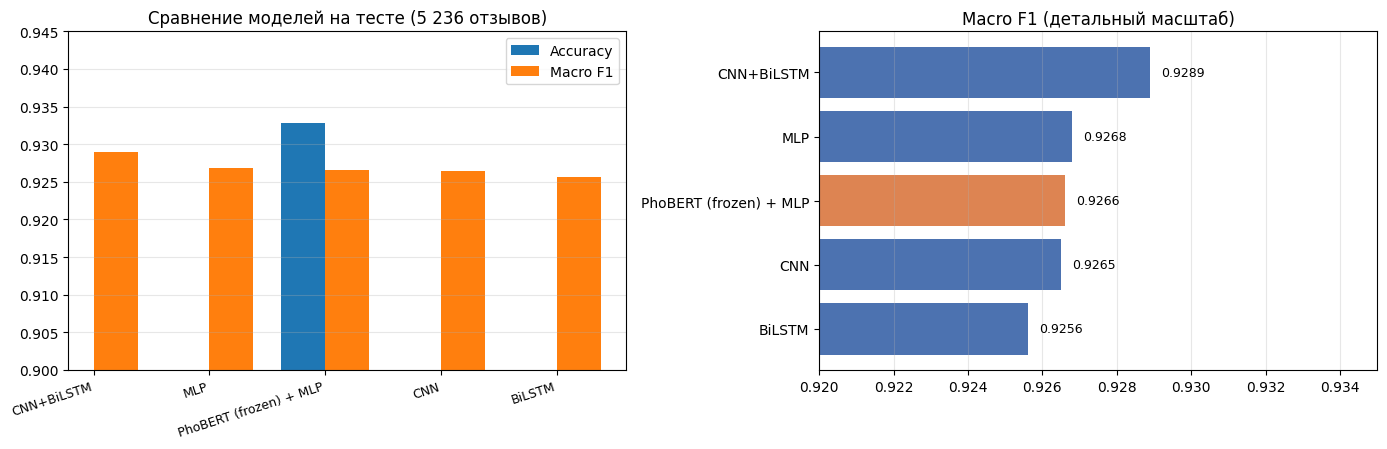

Лучшая модель: CNN+BiLSTM — acc nan, macro F1 0.9289


In [19]:
# Визуализация: Accuracy и macro F1
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
x = np.arange(len(comparison)); w = 0.38

axes[0].bar(x - w/2, comparison['accuracy'], w, label='Accuracy')
axes[0].bar(x + w/2, comparison['f1_macro'], w, label='Macro F1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['model'], rotation=18, ha='right', fontsize=9)
axes[0].set_ylim(0.90, 0.945); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_title('Сравнение моделей на тесте (5 236 отзывов)')

# Только macro F1, отсортировано — разброс между моделями виден лучше
axes[1].barh(comparison['model'][::-1], comparison['f1_macro'][::-1],
             color=['#4c72b0', '#4c72b0', '#dd8452', '#4c72b0', '#4c72b0'])
axes[1].set_xlim(0.920, 0.935)
for i, v in enumerate(comparison['f1_macro'][::-1]):
    axes[1].text(v + 0.0003, i, f'{v:.4f}', va='center', fontsize=9)
axes[1].set_title('Macro F1 (детальный масштаб)'); axes[1].grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

best = comparison.iloc[0]
print(f"Лучшая модель: {best['model']} — acc {best['accuracy']:.4f}, macro F1 {best['f1_macro']:.4f}")

## 2. По-классовое сравнение

Macro F1 по каждому из шести классов для всех пяти моделей.

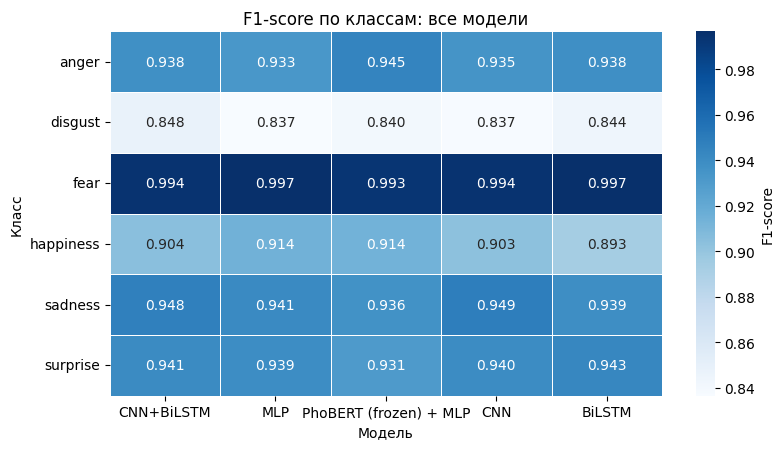

model,CNN+BiLSTM,MLP,PhoBERT (frozen) + MLP,CNN,BiLSTM
class,,,,,
anger,0.9376,0.9330,0.9452,0.9353,0.9383
disgust,0.8484,0.8366,0.8403,0.8373,0.8443
fear,0.9944,0.9967,0.9933,0.9944,0.9966
happiness,0.9041,0.9142,0.9137,0.9029,0.8929
sadness,0.9478,0.9412,0.9360,0.9486,0.9386
surprise,0.9409,0.9394,0.9309,0.9403,0.9429


In [20]:
# Собираем по-классовые отчёты: 4 DL-модели + PhoBERT
with open(f'{R}/per_class_reports.json') as f:
    dl_reports = json.load(f)
with open(f'{R}/phobert_metrics.json') as f:
    pho_report = json.load(f)['per_class_report']

rows = []
for model, rep in dl_reports.items():
    for cls in CLASSES:
        rows.append({'model': model, 'class': cls,
                     'precision': rep[cls]['precision'], 'recall': rep[cls]['recall'],
                     'f1': rep[cls]['f1-score']})
for cls in CLASSES:
    rows.append({'model': 'PhoBERT (frozen) + MLP', 'class': cls,
                 'precision': pho_report[cls]['precision'], 'recall': pho_report[cls]['recall'],
                 'f1': pho_report[cls]['f1-score']})
pc = pd.DataFrame(rows)
f1_pivot = pc.pivot(index='class', columns='model', values='f1')[comparison['model']]

plt.figure(figsize=(8.2, 4.6))
sns.heatmap(f1_pivot, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'F1-score'})
plt.title('F1-score по классам: все модели')
plt.ylabel('Класс'); plt.xlabel('Модель')
plt.tight_layout(); plt.show()
f1_pivot.round(4)

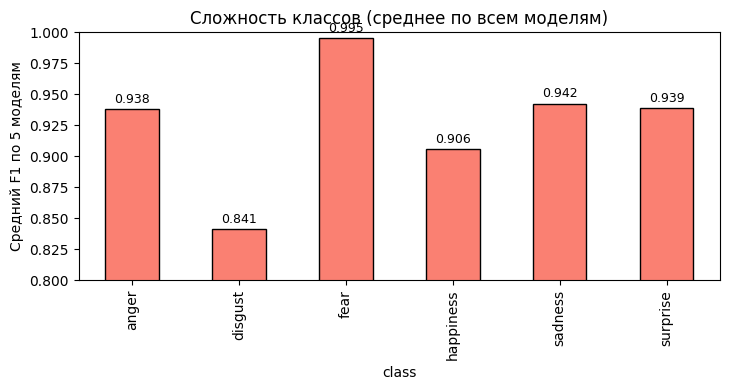

In [21]:
# Средний F1 по классам (по всем моделям) — какие классы трудные для ВСЕХ подходов
class_mean = pc.groupby('class')['f1'].mean().reindex(CLASSES)
ax = class_mean.plot(kind='bar', figsize=(7.4, 4), color='salmon', edgecolor='black')
for i, v in enumerate(class_mean):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylim(0.8, 1.0); ax.set_ylabel('Средний F1 по 5 моделям')
ax.set_title('Сложность классов (среднее по всем моделям)')
plt.tight_layout(); plt.show()

## 3. Оценка лучшей модели на тесте

Предсказания лучшей модели (`results/test_predictions_best.csv`) + дополнительные
метрики (`results/best_model_analysis.json`).

In [22]:
# Лучшая модель и её дополнительные метрики
with open(f'{R}/best_model_analysis.json') as f:
    best_info = json.load(f)
print(json.dumps(best_info, ensure_ascii=False, indent=1))

pred_df = pd.read_csv(f'{R}/test_predictions_best.csv')
y_true = pred_df['true_label']; y_pred = pred_df['predicted_label']

print('\nAccuracy:', round((y_true == y_pred).mean(), 4))
print(classification_report(y_true, y_pred, labels=CLASSES, digits=4))

{
 "best_model": "CNN+BiLSTM",
 "cohen_kappa": 0.9203,
 "matthews_corrcoef": 0.9209,
 "precision_weighted": 0.9376,
 "recall_weighted": 0.9339,
 "f1_weighted": 0.9345,
 "mean_confidence": 0.9664,
 "std_confidence": 0.0954
}

Accuracy: 0.9339
              precision    recall  f1-score   support

       anger     0.9247    0.9508    0.9376       956
     disgust     0.8438    0.8530    0.8484       551
        fear     0.9933    0.9955    0.9944       897
   happiness     0.8509    0.9645    0.9041       929
     sadness     0.9886    0.9101    0.9478       957
    surprise     0.9861    0.8996    0.9409       946

    accuracy                         0.9339      5236
   macro avg     0.9312    0.9289    0.9289      5236
weighted avg     0.9376    0.9339    0.9345      5236



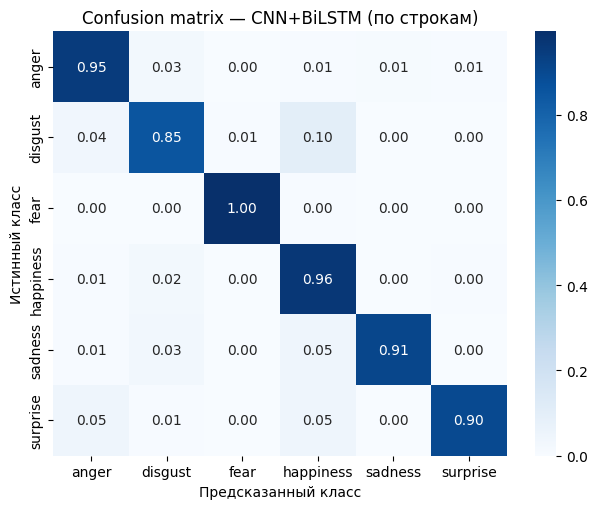

In [23]:
# Confusion matrix лучшей модели (по строкам)
cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(6.4, 5.2))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f"Confusion matrix — {best_info['best_model']} (по строкам)")
plt.ylabel('Истинный класс'); plt.xlabel('Предсказанный класс')
plt.tight_layout(); plt.show()

## 4. Анализ ошибок

In [24]:
# 4.1 Пары (истинный -> предсказанный), отсортированные по частоте ошибок
errs = pred_df[pred_df['correct'] == False]
pairs = (errs.groupby(['true_label', 'predicted_label']).size()
              .reset_index(name='count').sort_values('count', ascending=False))
print(f'Всего ошибок: {len(errs)} из {len(pred_df)}')
pairs.head(10)

Всего ошибок: 346 из 5236


,true_label,predicted_label,count
6,disgust,happiness,56
17,sadness,happiness,46
21,surprise,happiness,44
19,surprise,anger,44
15,sadness,disgust,33
0,anger,disgust,25
10,happiness,disgust,22
4,disgust,anger,20
2,anger,sadness,9
1,anger,happiness,7


## 5. Выводы

1. Все пять моделей образуют плотную группу: macro F1 от 0.9256 (BiLSTM) до
   0.9289 (CNN+BiLSTM) — разница лучшей и худшей модели меньше 0.4 п.п.
2. Лучшая модель — **CNN+BiLSTM** (acc 0.9339, macro F1 0.9289, κ = 0.9203,
   MCC = 0.9209): гибрид локальных n-грамм (CNN) и дальних зависимостей (BiLSTM).
3. Замороженный PhoBERT + MLP (macro F1 0.9266) конкурентен по accuracy
   (0.9328 — второй результат), но уступает по macro recall: без дообучения
   универсальное [CLS]-представление хуже разделяет похожие классы.
4. Класс **disgust** — самый трудный для всех моделей (средний F1 ≈ 0.845):
   частая путаница с happiness — отзывы о дефекте, исправленном поддержкой,
   смешивают лексику жалобы и благодарности. Это свойство данных, а не модели.
5. Класс **fear** узнаётся почти идеально всеми моделями (F1 > 0.993) благодаря
   характерной лексике (безопасность, гарантия, опасения).